In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import networkx as nx 
import graph_tool.all as gt 
import os
import sys
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import assembly_tree as at
sys.path.append('/Users/glover.co/Documents/laszlo/NetDesign/scripts')
import mcmc

In [2]:
prot_num = 1300
mol_num = 196
ikea_num = 102 

In [3]:
files = os.listdir('../data/circuits/ltspice_demos/edgefiles')
Xfiles = os.listdir('../data/circuits/ltspice_demos/Xfiles')
graphs = []
Xs = []
for f in files:
    if f.endswith('.edge'):
        g = nx.read_edgelist(os.path.join('../data/circuits/ltspice_demos/edgefiles', f),nodetype=int)
        graphs.append(g)
        X = np.loadtxt(os.path.join('../data/circuits/ltspice_demos/Xfiles', 'X_' + f.replace('.edge', '.txt')))
        Xs.append(X)


In [17]:
num_edges = [g.number_of_edges() for g in graphs]

In [18]:
max(num_edges)

121

In [19]:
X = Xs[19]
g = graphs[19]
O = at.extract_O(g,X)
capacity = at.extract_deg_cap(g,X).reshape(-1)

In [20]:
initial_graph = nx.Graph()
initial_graph.add_nodes_from(g.nodes())
at.prob_dist(X,O,capacity,T = 1000,initial_graph = initial_graph,rewire_est=True,max_edges=True)
# res = at.find_optimal_edge_count(X,O,capacity,initial_graph)

start milp
True


(array([1, 1, 1, 1, 1, 1, 1, 1, 2]),
 array([8, 7, 6, 5, 4, 3, 2, 1, 0]),
 True)

In [11]:
res.x

array([1., 0., 0., ..., 0., 0., 0.])

In [15]:
at.microcanonical_ensemble(X,O,capacity,initial_graph=initial_graph,T=1000)

In [32]:
np.argmax(num_edges)*2
nodes = initial_graph.nodes()

In [34]:
deg = initial_graph.degree()
X[nodes,:]@capacity - np.array([deg[i] for i in nodes])

array([[2., 2., 2., ..., 2., 2., 2.],
       [5., 5., 5., ..., 5., 5., 5.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [2., 2., 2., ..., 2., 2., 2.],
       [1., 1., 1., ..., 1., 1., 1.]])

In [22]:
protein_sp = np.loadtxt('../data/proteins/specificity.txt')
molecule_sp = np.loadtxt('../data/molecules/specificity.txt')
robots_sp = np.loadtxt('../data/robots/specificity.txt')
circuit_sp = np.loadtxt('../data/circuits/specificity.txt')
ikea_sp = np.loadtxt('../data/IkeaData/specificity.txt')

In [51]:
prot_y, prot_x = np.histogram(protein_sp, bins=40, range=(0,1))
mol_y, mol_x = np.histogram(molecule_sp, bins=40, range=(0,1))
ikea_y, ikea_x = np.histogram(ikea_sp, bins=40, range=(0,1))
circuit_y, circuit_x = np.histogram(circuit_sp, bins=40, range=(0,1))
robot_y, robot_x = np.histogram(robots_sp, bins=40, range=(0,1))
prot_y = prot_y / np.sum(prot_y)
mol_y = mol_y / np.sum(mol_y)
ikea_y = ikea_y / np.sum(ikea_y)
circuit_y = circuit_y / np.sum(circuit_y)
robot_y = robot_y / np.sum(robot_y)


In [52]:
prot_x = (prot_x[:-1] + prot_x[1:]) / 2
mol_x = (mol_x[:-1] + mol_x[1:]) / 2
ikea_x = (ikea_x[:-1] + ikea_x[1:]) / 2
circuit_x = (circuit_x[:-1] + circuit_x[1:]) / 2
robot_x = (robot_x[:-1] + robot_x[1:]) / 2


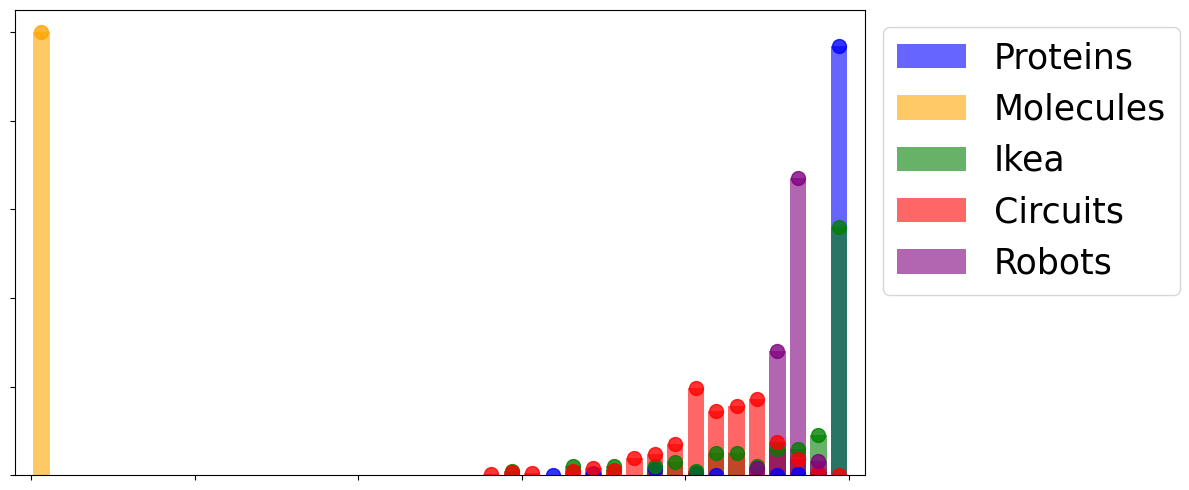

In [60]:
plt.figure(figsize=(12, 5))

# Filter and plot bars for Proteins
non_zero_prot = prot_y > 0
plt.bar(prot_x[non_zero_prot], prot_y[non_zero_prot], width=0.02, label='Proteins', color='blue', alpha=0.6)

# Filter and plot bars for Molecules
non_zero_mol = mol_y > 0
plt.bar(mol_x[non_zero_mol], mol_y[non_zero_mol], width=0.02, label='Molecules', color='orange', alpha=0.6)

# Filter and plot bars for Ikea
non_zero_ikea = ikea_y > 0
plt.bar(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], width=0.02, label='Ikea', color='green', alpha=0.6)

# Filter and plot bars for Circuits
non_zero_circuit = circuit_y > 0
plt.bar(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], width=0.02, label='Circuits', color='red', alpha=0.6)

# Filter and plot bars for Robots
non_zero_robot = robot_y > 0
plt.bar(robot_x[non_zero_robot], robot_y[non_zero_robot], width=0.02, label='Robots', color='purple', alpha=0.6)

# Add dots at the top of the bars
plt.scatter(prot_x[non_zero_prot], prot_y[non_zero_prot], color='blue', s=100, alpha=0.8)
plt.scatter(mol_x[non_zero_mol], mol_y[non_zero_mol], color='orange', s=100, alpha=0.8)
plt.scatter(ikea_x[non_zero_ikea], ikea_y[non_zero_ikea], color='green', s=100, alpha=0.8)
plt.scatter(circuit_x[non_zero_circuit], circuit_y[non_zero_circuit], color='red', s=100, alpha=0.8)
plt.scatter(robot_x[non_zero_robot], robot_y[non_zero_robot], color='purple', s=100, alpha=0.8)

plt.xticks(ticks=plt.xticks()[0], labels=[])
plt.yticks(ticks=plt.yticks()[0], labels=[])
plt.xlim(-.02, 1.02)
plt.ylim(0, 1.05)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/specificity_distributions.png', bbox_inches='tight', dpi=300)
plt.show()


In [61]:
ikea_sp[30]

np.float64(1.0)

In [72]:
np.min(protein_sp[protein_sp>0])

np.float64(0.625)

In [73]:
np.where(protein_sp == 0.625)

(array([316]),)

In [4]:
protein_sa = np.loadtxt('../data/proteins/sa.txt')
molecule_sa = np.loadtxt('../data/molecules/sa.txt')
robots_sa = np.loadtxt('../data/robots/sa.txt')
circuit_sa = np.loadtxt('../data/circuits/sa.txt')
ikea_sa = np.loadtxt('../data/IkeaData/sa.txt')

In [7]:
mol_names = []
with open('../params/molecules/mcmc_params.txt', 'r') as f:
    for line in f:
        mol_names.append(line.strip())

In [12]:
len('--graph_file /scratch/glover.co/NetDesign/data/molecules/WHO/edgefiles/')
mol_list = [m[71:].split(' ') for m in mol_names]
mol_list = [m[0] for m in mol_list]
mol_list = [m.replace('.edge','') for m in mol_list]
mol_list

['CID_10112',
 'CID_11029',
 'CID_11248',
 'CID_119432',
 'CID_165565',
 'CID_168924',
 'CID_17358',
 'CID_23665760',
 'CID_23668193',
 'CID_23668197',
 'CID_24083',
 'CID_24243',
 'CID_24266',
 'CID_24393',
 'CID_24424',
 'CID_24436',
 'CID_24439',
 'CID_24456',
 'CID_24462',
 'CID_24470',
 'CID_24934',
 'CID_25960',
 'CID_280',
 'CID_3032553',
 'CID_4101',
 'CID_445709',
 'CID_516900',
 'CID_5453',
 'CID_56955933',
 'CID_5702198',
 'CID_61745',
 'CID_6212',
 'CID_6374',
 'CID_64655',
 'CID_679',
 'CID_727',
 'CID_7628',
 'CID_76957057',
 'CID_784',
 'CID_10103319',
 'CID_10221470',
 'CID_1031',
 'CID_1046',
 'CID_11024312',
 'CID_1116159',
 'CID_1116160',
 'CID_11333',
 'CID_11358077',
 'CID_115056',
 'CID_11832956',
 'CID_118705487',
 'CID_122173797',
 'CID_12620',
 'CID_12675',
 'CID_131704316',
 'CID_131839611',
 'CID_132477936',
 'CID_132935795',
 'CID_13916',
 'CID_14052',
 'CID_14250',
 'CID_14251',
 'CID_146157093',
 'CID_154701625',
 'CID_157355',
 'CID_16058',
 'CID_16098',


In [19]:
sa_mol = [m for m in mol_list if molecule_sa[mol_list.index(m)] == 1]
sa_mol
np.savetxt('../data/sa_mol.txt', sa_mol, fmt='%s')

In [103]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / protein_sa[protein_sa > 0].sum()
mol_max_div_perc = mol_max_div.sum() / molecule_sa[molecule_sa > 0].sum()
robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()
circuit_max_div_perc = circuit_max_div.sum() / circuit_sa[circuit_sa > 0].sum()
ikea_max_div_perc = ikea_max_div.sum() / ikea_sa[ikea_sa > 0].sum()

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_14570/3005731854.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  robots_max_div_perc = robots_max_div.sum() / robots_sa[robots_sa > 0].sum()


In [104]:
prot_sa_y, prot_sa_x = np.histogram(protein_sa, bins=2, range=(0,1))
mol_sa_y, mol_sa_x = np.histogram(molecule_sa, bins=2, range=(0,1))
ikea_sa_y, ikea_sa_x = np.histogram(ikea_sa, bins=2, range=(0,1))
circuit_sa_y, circuit_sa_x = np.histogram(circuit_sa, bins=2, range=(0,1))
robot_sa_y, robot_sa_x = np.histogram(robots_sa, bins=2, range=(0,1))
prot_sa_y = prot_sa_y / np.sum(prot_sa_y)
mol_sa_y = mol_sa_y / np.sum(mol_sa_y)
ikea_sa_y = ikea_sa_y / np.sum(ikea_sa_y)
circuit_sa_y = circuit_sa_y / np.sum(circuit_sa_y)
robot_sa_y = robot_sa_y / np.sum(robot_sa_y)

In [105]:
prot_sa_x = (prot_sa_x[:-1] + prot_sa_x[1:]) / 2
mol_sa_x = (mol_sa_x[:-1] + mol_sa_x[1:]) / 2
ikea_sa_x = (ikea_sa_x[:-1] + ikea_sa_x[1:]) / 2
circuit_sa_x = (circuit_sa_x[:-1] + circuit_sa_x[1:]) / 2
robot_sa_x = (robot_sa_x[:-1] + robot_sa_x[1:]) / 2

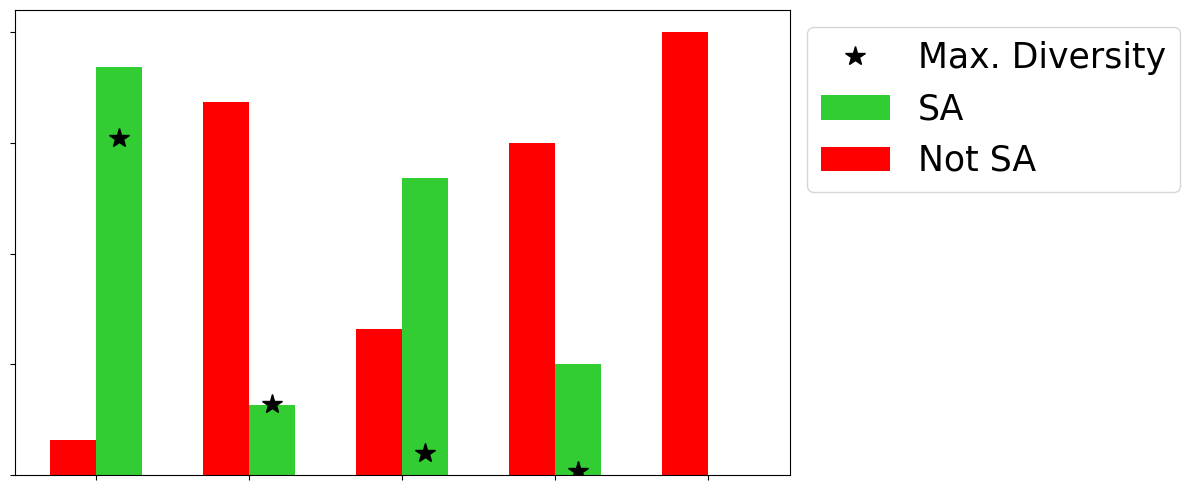

In [118]:
plt.figure(figsize=(12, 5))
# Make bar plots for each dataset side by side
plt.bar(.3, prot_sa_y[1], width=0.3, color='#32CD32', label='SA', alpha=1)
plt.bar(0, prot_sa_y[0], width=0.3, label='Not SA', color='red', alpha=1)
plt.bar(1, mol_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(1.3, mol_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(2, ikea_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(2.3, ikea_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(3, circuit_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(3.3, circuit_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.bar(4, robot_sa_y[0], width=0.3, color='red', alpha=1)
plt.bar(4.3, robot_sa_y[1], width=0.3, color='#32CD32', alpha=1)
plt.plot(.3, prot_max_div_perc, '*', color='black', markersize=15, label='Max. Diversity') 
plt.plot(1.3, mol_max_div_perc, '*', color='black', markersize=15)
plt.plot(2.3, ikea_max_div_perc, '*', color='black', markersize=15)
plt.plot(3.3, circuit_max_div_perc, '*', color='black', markersize=15)
plt.plot(4.3, robots_max_div_perc, '*', color='black', markersize=15)
plt.xticks([0.15, 1.15, 2.15, 3.15, 4.15], ['', '', '', '', ''])
plt.yticks(ticks=[0,.25,.5,.75,1.0], labels=[])
# plt.ylabel('Percentage of Self-Assembly')
plt.legend(loc='upper left',bbox_to_anchor=(1, 1),fontsize=25)
plt.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/self_assembly.pdf', bbox_inches='tight', dpi=300)


In [ ]:
prot_max_div = np.loadtxt('../data/proteins/max_diversity.txt')
mol_max_div = np.loadtxt('../data/molecules/max_diversity.txt')
robots_max_div = np.loadtxt('../data/robots/max_diversity.txt')
circuit_max_div = np.loadtxt('../data/circuits/max_diversity.txt')
ikea_max_div = np.loadtxt('../data/IkeaData/max_diversity.txt')
prot_max_div_perc = prot_max_div.sum() / 

In [101]:
prot_max_div.sum()

np.float64(851.0)

In [20]:
import pickle

In [100]:
with open('/Users/glover.co/Downloads/PGER.pkl', 'rb') as f:
    PGER = pickle.load(f)
with open('/Users/glover.co/Downloads/PGCM.pkl', 'rb') as f:
    PGCM = pickle.load(f)
with open('/Users/glover.co/Downloads/PGBA.pkl', 'rb') as f:
    PGBA = pickle.load(f)
with open('/Users/glover.co/Downloads/PGSB.pkl', 'rb') as f:
    PGSB = pickle.load(f)
with open('/Users/glover.co/Downloads/PGDCSBM_gt.pkl', 'rb') as f:
    PGDCSBM_gt = pickle.load(f)

In [213]:
g = PGDCSBM_gt[1][np.argmax(PGDCSBM_gt[0])]
edges = [(g.vertex_index[e.source()],g.vertex_index[e.target()]) for e in g.edges()]
edges

[(0, 5),
 (0, 6),
 (0, 8),
 (1, 3),
 (1, 9),
 (2, 3),
 (2, 4),
 (3, 4),
 (3, 9),
 (5, 1),
 (5, 8),
 (6, 8),
 (6, 9),
 (7, 8),
 (7, 4)]

/var/folders/8t/4z1vq2xd5790h0y5jrvphttr0000gp/T/ipykernel_67728/642480983.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


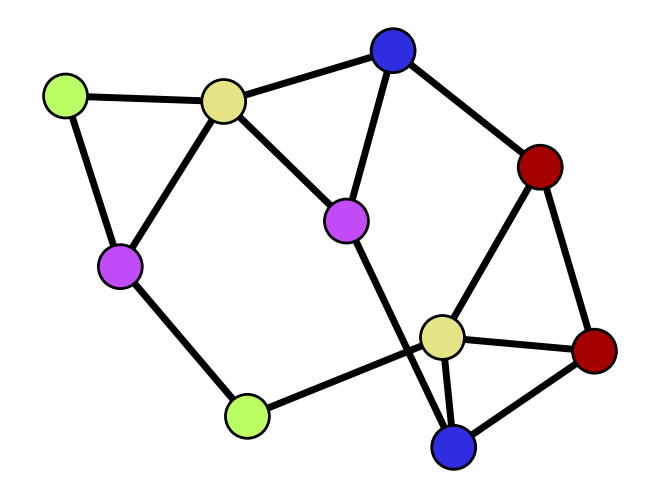

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]]


In [214]:
target = nx.read_edgelist('../data/proteins/human/edgefiles/CPX-8343.edge',nodetype=int)
X = np.loadtxt('../data/proteins/human/Xfiles/X_CPX-8343.txt')
# Add edge weight
# g = PGSB[1][np.argmin(PGSB[0])]
g = nx.Graph()
g.add_nodes_from(target.nodes())
g.add_edges_from(edges)
for u, v in g.edges():
    g[u][v]['weight'] = 5.0
color_map = {0: np.array([166,0,0])/256, 1: np.array([46,46,225])/256, 3: np.array([229,229,135])/256, 4: np.array([194,75,247])/256, 2: np.array([187, 255, 99])/256}
colors = [color_map[np.argmax(X[int(node)])] for node in target.nodes()]
pos = nx.kamada_kawai_layout(g)
at.draw_network(g,X,node_size=1000,pos=pos,linewidths=2,edgecolors='k',with_labels=False,colors=colors)
plt.tight_layout()
plt.savefig('figs/dcsbm_network_1.png', dpi=300)
plt.show()
print(X)

In [149]:
target_gt = gt.Graph(directed=False)
target_gt.add_vertex(len(target.nodes()))
target_gt.add_edge_list(target.edges())

Found ER isomorphic graph at idx 12375


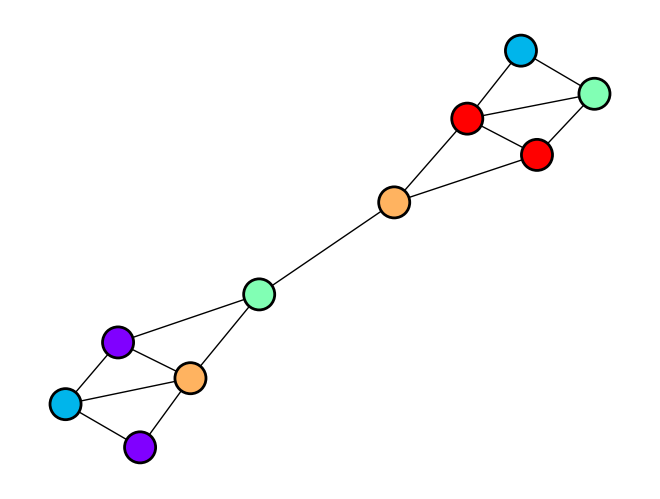

Found CM isomorphic graph at idx 831


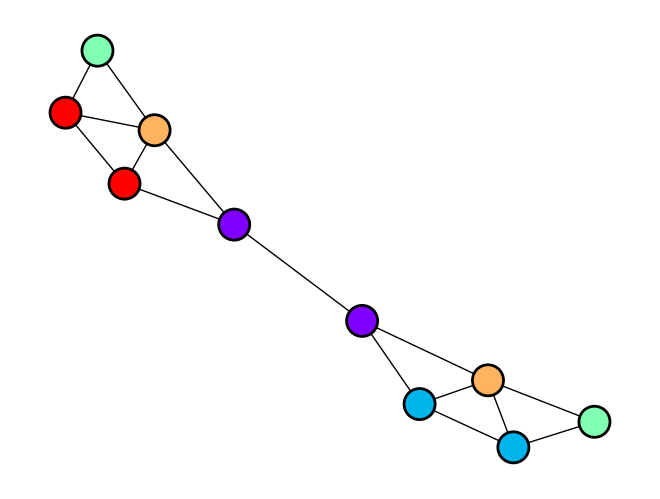

Found SB isomorphic graph at idx 0


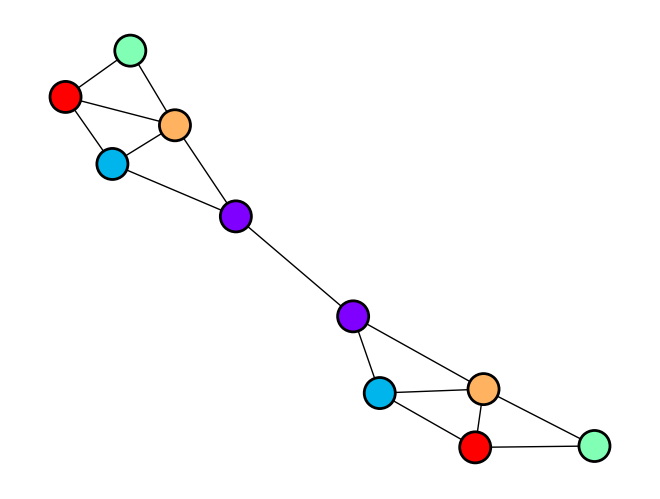

Found DCSBM_gt isomorphic graph at idx 64


In [150]:
for i, g in enumerate(PGER[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found ER isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGCM[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found CM isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGBA[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found BA isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGSB[1]):
    if nx.is_isomorphic(g, target):
        print(f'Found SB isomorphic graph at idx {i}')
        at.draw_network(g, X, node_size=500,linewidths=2,edgecolors='k')
        plt.show()
for i, g in enumerate(PGDCSBM_gt[1]):
    if gt.isomorphism(g, target_gt):
        print(f'Found DCSBM_gt isomorphic graph at idx {i}')


In [138]:
np.where(np.argsort(PGER[0]) == 12375)[0][0]

35133

<Figure size 500x500 with 0 Axes>

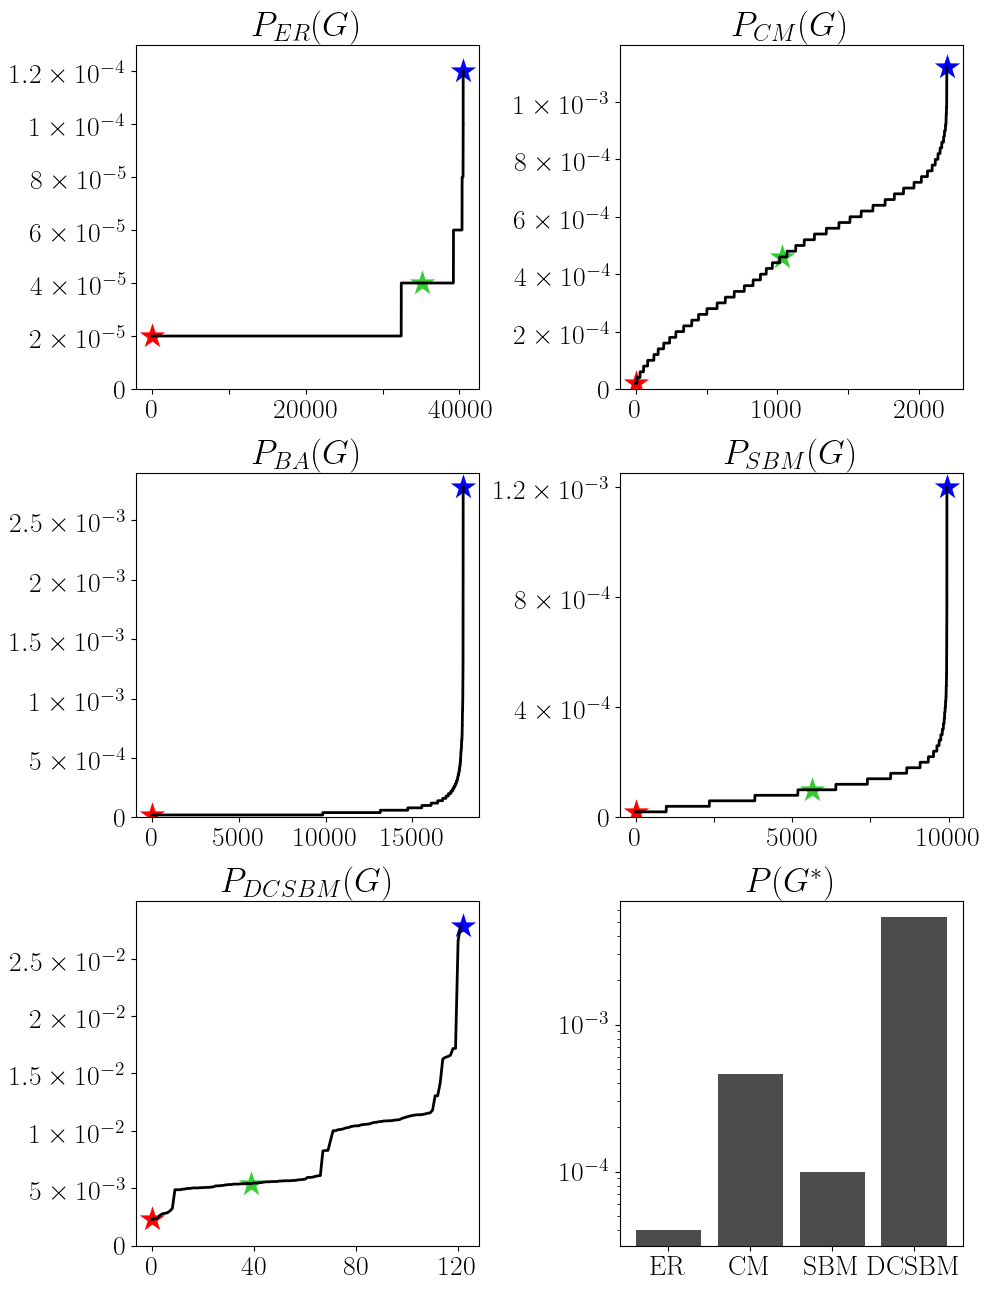

In [170]:
csfont = {'fontname':'Times New Roman'}
from matplotlib import rc
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)
fig = plt.figure(figsize=(5, 5))
fig, axs = plt.subplots(3,2,figsize=(10,13))
axs[0,0].plot(sorted(PGER[0])/np.sum(PGER[0]), color='k', linewidth=2, label='PGER',alpha=1)
axs[0,0].scatter(0, (sorted(PGER[0])/np.sum(PGER[0]))[0], marker='*', color='r', s=500, label='PGER', edgecolors='w')  # Increased size
axs[0,0].scatter(len(PGER[0]), (sorted(PGER[0])/np.sum(PGER[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[0,0].scatter(np.where(np.argsort(PGER[0]) == 12375)[0][0], ((PGER[0])/np.sum(PGER[0]))[12375], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[0,0].set_ylim(0,.00013)
axs[0,0].set_yticks(ticks=[0,.00002,.00004,.00006,.00008,.0001,.00012], labels=['0',r'$2\times 10^{-5}$', r'$4\times 10^{-5}$', r'$6\times 10^{-5}$', r'$8\times 10^{-5}$', r'$1\times 10^{-4}$', r'$1.2\times 10^{-4}$'],fontsize=20)
axs[0,0].set_xticks(ticks=[0,10000,20000,30000,40000], labels=['0', '', '20000', '', '40000'], fontsize=20)
axs[0,0].set_title(r'$P_{ER}(G)$', fontsize=25)
axs[0,1].plot(sorted(PGCM[0])/np.sum(PGCM[0]), color='k', linewidth=2, label='PGCM',alpha=1)
axs[0,1].scatter(0, (sorted(PGCM[0])/np.sum(PGCM[0]))[0], marker='*', color='r', s=500, label='PGCM', edgecolors='w')  # Increased size
axs[0,1].scatter(len(PGCM[0]), (sorted(PGCM[0])/np.sum(PGCM[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[0,1].scatter(np.where(np.argsort(PGCM[0])==831)[0][0], ((PGCM[0])/np.sum(PGCM[0]))[831], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[0,1].set_ylim(0,.0012)
axs[0,1].set_yticks(ticks=[0,.0002,.0004,.0006,.0008,0.001], labels=['0',r'$2\times 10^{-4}$', r'$4\times 10^{-4}$', r'$6\times 10^{-4}$', r'$8\times 10^{-4}$', r'$1\times 10^{-3}$'],fontsize=20)
axs[0,1].set_xticks(ticks=[0,500,1000,1500,2000], labels=['0', '', '1000', '', '2000'], fontsize=20)
axs[0,1].set_title(r'$P_{CM}(G)$', fontsize=25)
axs[1,0].plot(sorted(PGBA[0])/np.sum(PGBA[0]), color='k', linewidth=2, label='PGBA',alpha=1)
axs[1,0].scatter(0, (sorted(PGBA[0])/np.sum(PGBA[0]))[0], marker='*', color='r', s=500, label='PGBA', edgecolors='w')  # Increased size
axs[1,0].scatter(len(PGBA[0]), (sorted(PGBA[0])/np.sum(PGBA[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[1,0].set_ylim(0,.0029)
axs[1,0].set_yticks(ticks=[0,.0005,.001,.0015,.002,.0025], labels=['0',r'$5\times 10^{-4}$', r'$1\times 10^{-3}$', r'$1.5\times 10^{-3}$', r'$2\times 10^{-3}$', r'$2.5\times 10^{-3}$'],fontsize=20)
axs[1,0].set_xticks(ticks=[0,5000,10000,15000], labels=['0', '5000', '10000', '15000'], fontsize=20)
axs[1,0].set_title(r'$P_{BA}(G)$', fontsize=25)
axs[1,1].plot(sorted(PGSB[0])/np.sum(PGSB[0]), color='k', linewidth=2, label='PGSB',alpha=1)
axs[1,1].scatter(0, (sorted(PGSB[0])/np.sum(PGSB[0]))[0], marker='*', color='r', s=500, label='PGSB', edgecolors='w')  # Increased size
axs[1,1].scatter(len(PGSB[0]), (sorted(PGSB[0])/np.sum(PGSB[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[1,1].scatter(np.where(np.argsort(PGSB[0])==0)[0][0], ((PGSB[0])/np.sum(PGSB[0]))[0], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[1,1].set_ylim(0,.00125)
axs[1,1].set_yticks(ticks=[0,.0004,.0008,0.0012], labels=['0', r'$4\times 10^{-4}$', r'$8\times 10^{-4}$', r'$1.2\times 10^{-3}$'],fontsize=20)
axs[1,1].set_xticks(ticks=[0,2500,5000,7500,10000], labels=['0', '', '5000', '', '10000'], fontsize=20)
axs[1,1].set_title(r'$P_{SBM}(G)$', fontsize=25)
axs[2,0].plot(sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]), color='k', linewidth=2, label='PGDCSBM_gt',alpha=1)
axs[2,0].scatter(0, (sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[0], marker='*', color='r', s=500, label='PGDCSBM_gt', edgecolors='w')  # Increased size
axs[2,0].scatter(len(PGDCSBM_gt[0]), (sorted(PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[-1], marker='*', color='b', s=500, edgecolors='w')  # Increased size
axs[2,0].scatter(np.where(np.argsort(PGDCSBM_gt[0])==64)[0][0], ((PGDCSBM_gt[0])/np.sum(PGDCSBM_gt[0]))[64], marker='*', color='limegreen', s=500, edgecolors='w')  # Increased size
axs[2,0].set_ylim(0,.03)
axs[2,0].set_yticks(ticks=[0,.005,.01,.015,.02,.025], labels=['0', r'$5\times 10^{-3}$', r'$1\times 10^{-2}$', r'$1.5\times 10^{-2}$', r'$2\times 10^{-2}$', r'$2.5\times 10^{-2}$'],fontsize=20)
axs[2,0].set_xticks(ticks=[0,40,80,120], labels=['0', '40', '80', '120'], fontsize=20)
axs[2,0].set_title(r'$P_{DCSBM}(G)$', fontsize=25)
axs[2,1].bar([0,1,2,3],[PGER[0][12375]/np.sum(PGER[0]), PGCM[0][831]/np.sum(PGCM[0]), PGSB[0][0]/np.sum(PGSB[0]), PGDCSBM_gt[0][64]/np.sum(PGDCSBM_gt[0])], color=['k','k','k','k'], alpha=0.7)
axs[2,1].set_xticks([0,1,2,3], labels=[r'ER', r'CM', r'SBM', r'DCSBM'], fontsize=20)
# Make font of yticks size 20
axs[2,1].set_yticks(ticks=[1e-6,1e-5,1e-4,1e-3], labels=[r'$10^{-6}$', r'$10^{-5}$', r'$10^{-4}$', r'$10^{-3}$'], fontsize=20)
axs[2,1].set_yscale('log')
axs[2,1].set_title(r'$P(G^*)$', fontsize=25)
# Add padding between plots
fig.tight_layout()
plt.savefig('/Users/glover.co/CCNR Dropbox/Success Team/Glover, Cory/network_design/drafts/Network-Design-March-2025-/v10/figs/probability_distributions.pdf', bbox_inches='tight', dpi=300)
plt.show()